In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import xarray as xr
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import cartopy.crs as ccrs
from matplotlib.patches import Polygon

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 18})

# About
__Date:__ 03/14/25  
__Author:__ Pat McCornack  
__Purpose:__ This notebook explores alternate low cloud representations in WRF, using the QCLOUD and CLDFRA variables instead of wrf-python wrf.cloudfrac. 

# Functions

In [2]:
def extract_vertical(var_ds, sites_df):
    df = pd.DataFrame() 
    for i, row in sites_df.iterrows():
        ds = var_ds.sel(lat=row['lat'], lon=row['lon'], method='nearest')
        ds = ds.mean(dim='time')
        site_df = ds.squeeze().to_dataframe()
        site_df = site_df.drop(['lat', 'lon'], axis=1)
        site_df['site'] = row['site']
        df = pd.concat([df, site_df])
    return df

In [ ]:
# Open datasets
root_dir = Path().resolve().parent
terrain_fpath = root_dir / 'data' / 'wrf-extracted' / 'height_agl.nc'
qcloud_fpath = root_dir / 'data' / 'wrf-extracted' / 'wrf-qcloud.nc'
cldfrc_fpath = root_dir / 'data' / 'wrf-extracted' / 'wrf-cldfra.nc'
goes_fpath = root_dir / 'data' / 'geospatial' / 'clemesha-clc' / 'cldalb-sci.nc'

# Open datasets
terrain_ds = xr.open_dataarray(terrain_fpath)
qcloud_da = xr.open_dataarray(qcloud_fpath)
cldfra_da = xr.open_dataarray(cldfrc_fpath)
goes_da = xr.open_dataarray(goes_fpath)

# Remove duplicates - these were extracted twice 
qcloud_da = qcloud_da.groupby('time').mean()
cldfra_da = cldfra_da.groupby('time').mean()

# Format GOES timestamps
goes_da['time'] = pd.to_datetime(goes_da['time'].values).ceil('30min')  # Round off

# Subset WRF to daylight hours 
common_times = goes_da['time'].values[np.isin(goes_da['time'], cldfra_da['time'])]

goes_da = goes_da.sel(time=common_times)
cldfra_da = cldfra_da.sel(time=common_times)
qcloud_da = qcloud_da.sel(time=common_times)

times = cldfra_da['time'].to_dataframe().reset_index(drop=True)
times = pd.to_datetime(times['time'])
times.dt.hour.unique()

# Get common lat/lon extent around SCI
latmax, latmin = np.min([cldfra_da['lat'].max(), goes_da['lat'].max()]), np.max([cldfra_da['lat'].min(), goes_da['lat'].min()])
lonmax, lonmin = np.min([cldfra_da['lon'].max(), goes_da['lon'].max()]), np.max([cldfra_da['lon'].min(), goes_da['lon'].min()])

cldfra_da = cldfra_da.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))
qcloud_da = qcloud_da.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))
goes_da = goes_da.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))

# Reindex GOES to align with WRF
goes_da = goes_da.reindex_like(cldfra_da, method='nearest')


In [14]:
## !!!! TEMPORARY - Changed extraction method

# Define bounds
bound_dict = {
    'latmax' : 34.2,
    'latmin' : 33.8,
    'lonmax' : -119.48,
    'lonmin' : -119.98
}

# Extract bounds
latmin, latmax = bound_dict['latmin'], bound_dict['latmax']
lonmin, lonmax = bound_dict['lonmin'], bound_dict['lonmax']

terrain_ds = terrain_ds.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))  # Subset to SCI

# Merge datasets
qcloud_ds = xr.Dataset({'qcloud' : qcloud_da, 'height_agl' : terrain_ds})
cldfra_ds = xr.Dataset({'cldfra' : cldfra_da, 'height_agl' : terrain_ds})

# Filter to low clouds
qcloud_ds = qcloud_ds.where(qcloud_ds.height_agl <= 2000).dropna(dim='bottom_top')
cldfra_ds = cldfra_ds.where(cldfra_ds.height_agl <= 2000).dropna(dim='bottom_top')

In [18]:
# Extract max value from vertical column 
qcloud_da = qcloud_ds['qcloud'].max(dim='bottom_top')
cldfra_da = cldfra_ds['cldfra'].max(dim='bottom_top')

# Join all data
clc_ds = xr.Dataset({'goes' : goes_da, 'qcloud' : qcloud_da, 'cldfra' : cldfra_da})
clc_ds

<xarray.Dataset> Size: 87MB
Dimensions:  (lon: 99, lat: 88, time: 834)
Coordinates:
  * lon      (lon) float64 792B -120.0 -120.0 -120.0 ... -119.5 -119.5 -119.5
  * lat      (lat) float64 704B 33.8 33.8 33.81 33.81 ... 34.19 34.19 34.2 34.2
  * time     (time) datetime64[ns] 7kB 1996-05-31T17:00:00 ... 1996-08-04T16:...
Data variables:
    goes     (time, lat, lon) float32 29MB 0.66 nan 1.08 nan ... 1.69 nan 1.42
    qcloud   (time, lat, lon) float32 29MB nan nan nan nan ... nan nan nan nan
    cldfra   (time, lat, lon) float32 29MB nan nan nan nan ... nan nan nan nan

# Explore Data

## Vertical Profiles

In [33]:
# Extract vertical profiles
site_dict = {
    'site' : ['west-end', 'coche-point', 'inland', 'north-ocean'],
    'lat' : [34.012499, 34.033456, 34.00346, 34.08375],
    'lon' : [-119.882897, -119.600946, -119.76288, -119.68265]
}
sites_df = pd.DataFrame(site_dict)

qcloud_df = extract_vertical(qcloud_ds, sites_df)
cldfra_df = extract_vertical(cldfra_ds, sites_df)

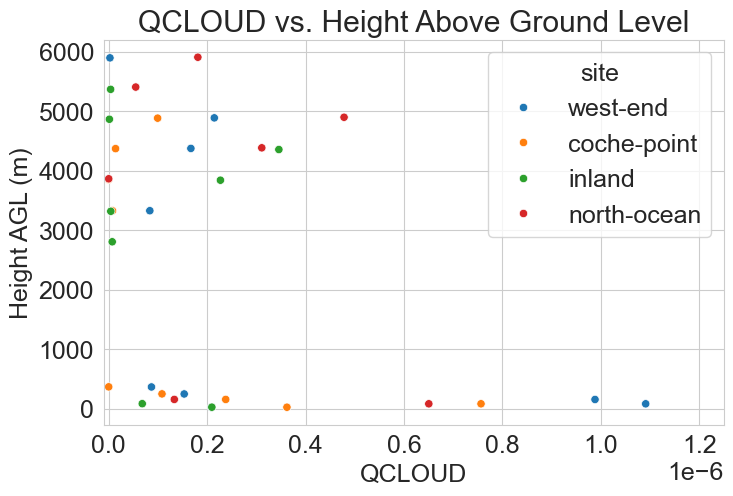

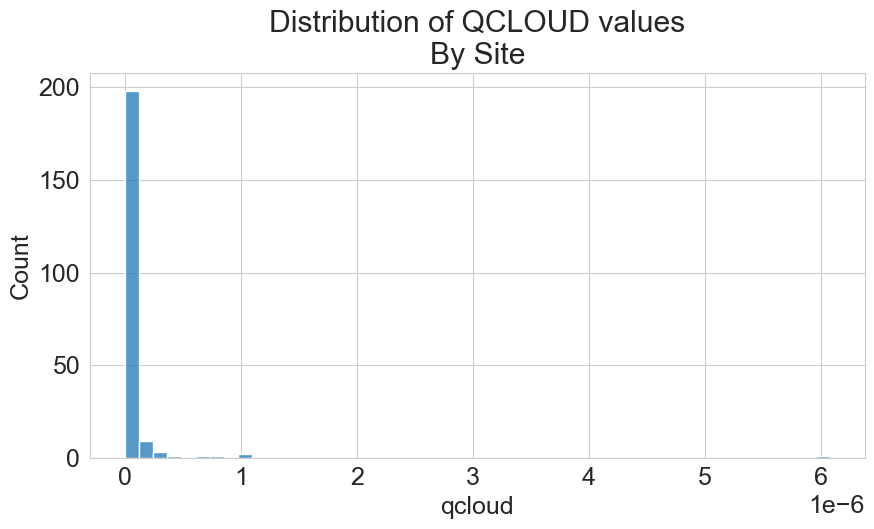

In [34]:
# QCLOUD Vertical Profile
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=qcloud_df.loc[qcloud_df['qcloud']!=0],
                x='qcloud',
                y='height_agl',
                hue='site')  # height_agl
ax.set_xlim(-1e-8, 1.25e-6)
ax.set(title=f'QCLOUD vs. Height Above Ground Level',
    xlabel='QCLOUD',
    ylabel='Height AGL (m)')
plt.show()

# QCLOUD Histogram
fig, ax = plt.subplots(figsize=(10,5))
sns.histplot(qcloud_df['qcloud'],
             bins=50)
ax.set(title='Distribution of QCLOUD values\nBy Site')
plt.show()

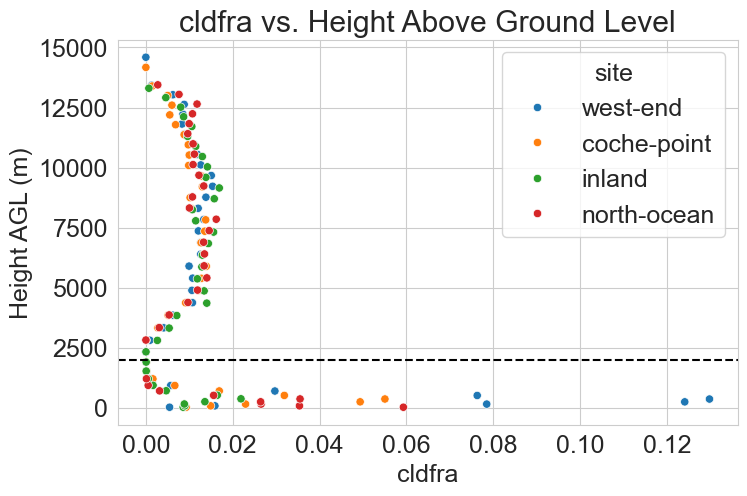

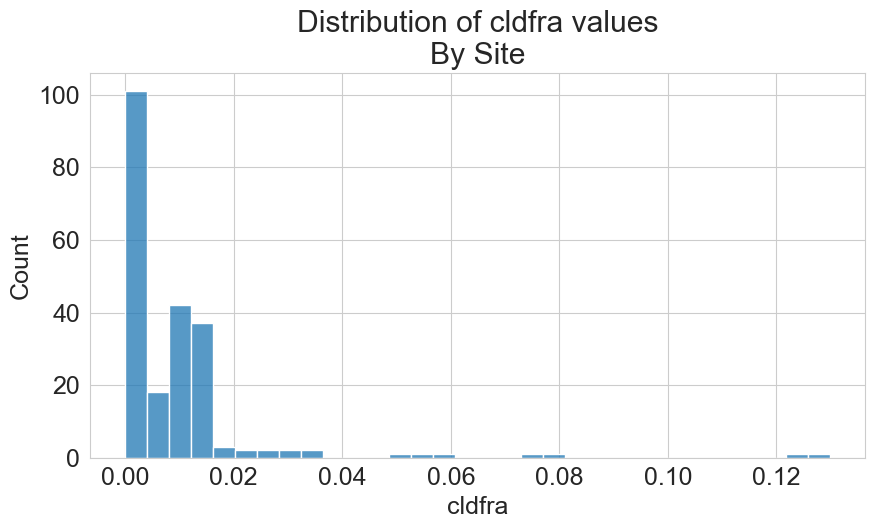

In [35]:
# cldfra Vertical Profile
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=cldfra_df.loc[cldfra_df['cldfra']!=0],
                x='cldfra',
                y='height_agl',
                hue='site')  # height_agl

ax.set(title='cldfra vs. Height Above Ground Level',
    xlabel='cldfra',
    ylabel='Height AGL (m)')
plt.axhline(y=2000, color='black', linestyle='--')
plt.show()

# cldfra Histogram
fig, ax = plt.subplots(figsize=(10,5))
sns.histplot(cldfra_df['cldfra'])
ax.set(title='Distribution of cldfra values\nBy Site')
plt.show()

# Subset to only low clouds (<2000m AGL)

# Combine data

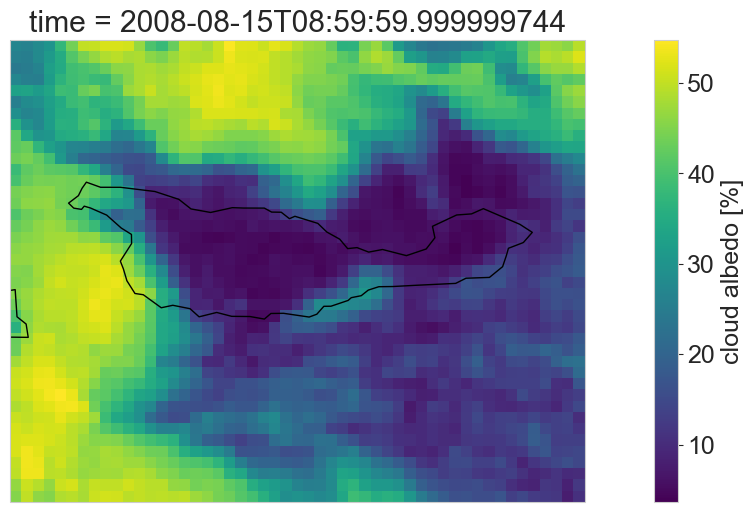

In [37]:
# Load in GOES Dataset
goes_da = xr.open_dataarray(goes_fpath)
tmp = goes_da.sel(time='2008-08-15T09:00:00.000000000', method='nearest')

fig, ax = plt.subplots(figsize=(18,6), subplot_kw={'projection' : ccrs.PlateCarree()})
tmp.plot()
ax.coastlines()
plt.show()

In [ ]:
# Extract max value from vertical column 
qcloud_da = qcloud_ds['qcloud'].max(dim='bottom_top')
cldfra_da = cldfra_ds['cldfra'].max(dim='bottom_top')

# Close datasets to preserve memory
qcloud_ds.close()
cldfra_ds.close()

# Align clc dataset with WRF datasets
goes_da = goes_da.reindex_like(goes_da, method='nearest')

In [39]:
clc_ds = xr.Dataset({'qcloud' : qcloud_da, 'cldfra' : cldfra_da, 'goes' : goes_da})
clc_ds

KeyboardInterrupt: 